# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import pickle
import pickle

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import the datasets

In [2]:
# Import the datasets
convabuse = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/convabuse_final.csv')
dynamically_generated_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/dynamically_generated_hate_speech_dataset_final.csv')
online_abusive_attacks = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/online_abusive_attacks_final.csv')
us_elections_2020_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/us_elections_2020_hate_speech_final.csv')
mlma_hate_speech = pd.read_csv('/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/MLMA_hate_speech_final.csv')

## Split the datasets

In [3]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,2,1,0,0,0,0,0,0,0
1,7,1,0,0,0,0,0,0,0
2,5,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0
4,3,1,0,0,0,0,0,0,0


In [4]:
convabuse_X = convabuse.drop("abuse_level", axis=1)
convabuse_y = convabuse["abuse_level"]

Drop the "Unnamed: 0" column from this and future modeling iterations.

In [5]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,-1,4,0,1
1,1.0,-1,9,1,1
2,1.0,-1,16,1,0
3,1.0,0,2,0,1
4,1.0,-1,15,0,1


In [6]:
dynamically_generated_hate_speech_X = dynamically_generated_hate_speech.drop("label", axis=1)
dynamically_generated_hate_speech_y = dynamically_generated_hate_speech["label"]

In [7]:
online_abusive_attacks.head()

,Parent tweets,Replies to parents,Avg replies per parent,Parent tweets with replies,Avg replies per parent with replies,Toxic parent tweets,Non-toxic parent tweets,Toxic replies,Non-toxic replies,Toxic replies to non-toxic parents,...,Love,News,Account,Feminist,Official,Follow,Products,Tweets,Womens,Toxicity
0,377.0,696.0,1.846154,102.0,6.823529,0.0,377.0,0.0,696.0,0.0,...,0,0,0,0,0,0,0,0,0,0.0
1,1171.0,252.0,0.215201,87.0,2.896552,67.0,1104.0,13.0,239.0,11.0,...,0,0,0,0,0,0,0,0,0,80.0
2,1009.0,1505.0,1.491576,444.0,3.389640,28.0,981.0,45.0,1460.0,38.0,...,0,0,0,0,0,0,0,0,0,73.0
3,1087.0,1303.0,1.198712,411.0,3.170316,47.0,1040.0,49.0,1254.0,43.0,...,0,0,0,0,0,0,0,0,0,96.0
4,1185.0,147.0,0.124051,58.0,2.534483,97.0,1088.0,7.0,140.0,7.0,...,0,0,0,0,0,0,0,0,0,104.0


In [8]:
online_abusive_attacks_X = online_abusive_attacks.drop("Toxicity", axis=1)
online_abusive_attacks_y = online_abusive_attacks["Toxicity"]

In [9]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,-1,0,1,1
1,1,0,1,1
2,1,0,1,1
3,-1,0,1,1
4,0,-1,1,1


In [10]:
us_elections_2020_hate_speech_X = us_elections_2020_hate_speech.drop("HOF", axis=1)
us_elections_2020_hate_speech_y = us_elections_2020_hate_speech["HOF"]

In [11]:
mlma_hate_speech.head()

,index,shock_annotator_sentiment,anger_annotator_sentiment,confusion_annotator_sentiment,sadness_annotator_sentiment,indifference_annotator_sentiment,disgust_annotator_sentiment,fear_annotator_sentiment,implicit,explicit,Abusive,Not Abusive,Very Abusive,Very Strongly Abusive,target_groups
0,1867,0,0,0,0,0,1,0,0,1,0,0,1,0,0
1,18067,0,0,0,0,1,0,0,1,0,1,0,0,0,0
2,15630,0,0,0,0,1,1,0,0,1,1,0,0,0,0
3,1019,0,0,0,0,0,1,0,0,1,0,0,1,0,0
4,16794,0,0,0,0,1,0,0,1,0,0,1,0,0,0


In [12]:
mlma_hate_speech_X = mlma_hate_speech.drop(columns=["target_groups", "index"], axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]

# Linear Modeling

In [13]:
# Import LinearRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [14]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dynamically_generated_hate_speech_X_numeric = dynamically_generated_hate_speech_X.select_dtypes(include=np.number)
online_abusive_attacks_X_numeric = online_abusive_attacks_X.select_dtypes(include=np.number)
us_elections_2020_hate_speech_X_numeric = us_elections_2020_hate_speech_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)

In [15]:
# Use standard scaler on the Convabuse X data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [16]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dynamically_generated_hate_speech_X_scaled = dghs_scaler.fit_transform(dynamically_generated_hate_speech_X_numeric)
dynamically_generated_hate_speech_X_scaled = pd.DataFrame(dynamically_generated_hate_speech_X_scaled, columns=dynamically_generated_hate_speech_X_numeric.columns)

In [17]:
# Use standard scaler on the online abusive attacks X data
oaa_scaler = StandardScaler()
online_abusive_attacks_X_scaled = oaa_scaler.fit_transform(online_abusive_attacks_X_numeric)
online_abusive_attacks_X_scaled = pd.DataFrame(online_abusive_attacks_X_scaled, columns=online_abusive_attacks_X_numeric.columns)

In [18]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us_elections_2020_hate_speech_X_scaled = us2020hs_scaler.fit_transform(us_elections_2020_hate_speech_X_numeric)
us_elections_2020_hate_speech_X_scaled = pd.DataFrame(us_elections_2020_hate_speech_X_scaled, columns=us_elections_2020_hate_speech_X_numeric.columns)

In [19]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [20]:
for columns in [convabuse_X_numeric.columns, dynamically_generated_hate_speech_X_numeric.columns, online_abusive_attacks_X_numeric.columns, us_elections_2020_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'generalised', 'individual', 'system',
       'explicit', 'implicit', 'target_groups'],
      dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Parent tweets', 'Replies to parents', 'Avg replies per parent',
       'Parent tweets with replies', 'Avg replies per parent with replies',
       'Toxic parent tweets', 'Non-toxic parent tweets', 'Toxic replies',
       'Non-toxic replies', 'Toxic replies to non-toxic parents',
       'Non-toxic replies to non-toxic parents',
       'Toxic replies to toxic parents', 'Non-toxic replies to toxic parents',
       'Followers_count', 'Friends_count', 'Listed_count', 'Favourites_count',
       'Verified', 'Statuses_count', 'Retweet_count min', 'Retweet_count avg',
       'Retweet_count max', 'Favorite_count min', 'Favorite_count avg',
       'Favorite_count max', 'Possibly_sensitive',
       'Repliers with min 1 toxic reply', 'High toxicity parents',
       'High severe_to

In [21]:
mlma_hate_speech_y.unique()

array([0, 2, 3, 1])

In [22]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_scaled, convabuse_y, test_size=0.2, random_state=42, stratify=convabuse_y)
dynamically_generated_hate_speech_X_train, dynamically_generated_hate_speech_X_test, dynamically_generated_hate_speech_y_train, dynamically_generated_hate_speech_y_test = train_test_split(dynamically_generated_hate_speech_X_scaled, dynamically_generated_hate_speech_y, test_size=0.2, random_state=42, stratify=dynamically_generated_hate_speech_y)
online_abusive_attacks_X_train, online_abusive_attacks_X_test, online_abusive_attacks_y_train, online_abusive_attacks_y_test = train_test_split(online_abusive_attacks_X_scaled, online_abusive_attacks_y, test_size=0.2, random_state=42)
us_elections_2020_hate_speech_X_train, us_elections_2020_hate_speech_X_test, us_elections_2020_hate_speech_y_train, us_elections_2020_hate_speech_y_test = train_test_split(us_elections_2020_hate_speech_X_scaled, us_elections_2020_hate_speech_y, test_size=0.2, random_state=42, stratify=us_elections_2020_hate_speech_y)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_scaled, mlma_hate_speech_y, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y)

In [23]:
import umap
from sklearn.manifold import TSNE


def linear_modeling(dataset, X_train, X_test, y_train, y_test, target):
  # Perform linear regression on the dataset
  linear_model = LinearRegression()
  linear_model = linear_model.fit(X_train, y_train)
  linear_y_pred = linear_model.predict(X_test)
  linear_rmse = root_mean_squared_error(y_test, linear_y_pred)
  linear_r2 = r2_score(y_test, linear_y_pred)
  print(f"RMSE: {linear_rmse}")
  print(f"R2: {linear_r2}")

  # Get the coefficients for each feature
  linear_coefficients = linear_model.coef_

  # Create a list of column names (assuming they are indexed from 0 to n-1)
  # This handles both pandas DataFrames and NumPy arrays
  if isinstance(X_train, pd.DataFrame):
    column_names = X_train.columns.tolist()
  else:
    column_names = [i for i in range(X_train.shape[1])]

  # Create a dictionary of all coefficients in the original order
  coefficients_data = dict(zip(column_names, linear_coefficients))

  # Sort the feature importances
  linear_columns_sorted = np.argsort(linear_coefficients)[::-1]
  linear_coefficients_sorted = linear_coefficients[linear_columns_sorted]

  # Select the top 10 features and their coefficients (or all if less than 10)
  num_features_to_plot = min(10, len(linear_columns_sorted))
  top_features_indices = linear_columns_sorted[:num_features_to_plot]
  top_coefficients = linear_coefficients_sorted[:num_features_to_plot]

  # Get the names of the top features
  top_feature_names = [column_names[i] for i in top_features_indices]

  # Create a dictionary using the top 10 features and top 10 coefficients
  top_coefficients_data = {
      feature: importance for feature, importance in zip(top_feature_names, top_coefficients)
  }

  # Create a sorted dictionary by value in descending order for output and plotting
  top_coefficients_output = dict(sorted(top_coefficients_data.items(), key=lambda item: item[1], reverse=True))


  # Print the dictionary
  print("Top Coefficients")
  print(top_coefficients_output)


  print("Linear Coefficients")
  print(coefficients_data)

  # Plot the top 10 coefficients as a horizontal bar chart
  plt.figure(figsize=(10, 6))
  # Use the actual integer indices of the top 10 features as labels, sorted by value
  sns.barplot(x=list(top_coefficients_output.values()), y=list(top_coefficients_output.keys()), orient='h', palette='hot')
  plt.xlabel('Coefficient Value')
  plt.ylabel('Feature')
  plt.title(f'Top {num_features_to_plot} Feature Coefficients for {dataset} Linear Model')
  plt.show()


  # Plot the linear model
  plt.figure(figsize=(10, 6))
  scatter = plt.scatter(y_test, linear_y_pred, c=y_test, cmap='hot')
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
  plt.xlabel(f"Actual {target}")
  plt.ylabel(f"Predicted {target}")
  plt.title(f"{dataset} Linear Model")
  plt.colorbar(scatter, label=f"{target}")
  plt.show()

  # Use t-sne and color code by the target variable

  # Reduce dimensionality of test data using t-SNE
  tsne_test = TSNE(n_components=2, random_state=42)
  X_test_tsne = tsne_test.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} User Dataset')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  # Use t-sne to plot correct vs incorrect predictions
  # Calculate if predictions are correct (within a tolerance)
  tolerance = 0.5  # Define a tolerance for what is considered "correct"
  correct_predictions = np.abs(linear_y_pred - y_test) <= tolerance

  # Create a scatter plot, coloring by correctness
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_tsne[:, 0], X_test_tsne[:, 1], c=correct_predictions, cmap='hot', alpha=0.6)
  plt.title(f't-SNE Visualization of {dataset} Test Data: Correct vs Incorrect Predictions')
  plt.xlabel('t-SNE Component 1')
  plt.ylabel('t-SNE Component 2')
  cbar = plt.colorbar(scatter, ticks=[0, 1])
  cbar.ax.set_yticklabels(['Incorrect', 'Correct'])
  plt.show()

  # Use UMAP and color code by the target variable
  # Reduce dimensionality using UMAP
  reducer = umap.UMAP(random_state=42)
  X_test_umap = reducer.fit_transform(X_test)

  # Create a scatter plot
  plt.figure(figsize=(10, 8))
  scatter = plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='hot', alpha=0.6)
  plt.title(f'UMAP Visualization of {dataset} User Dataset')
  plt.xlabel('UMAP Component 1')
  plt.ylabel('UMAP Component 2')
  plt.colorbar(scatter, label=f'{target}')
  plt.show()

  return linear_rmse, linear_r2, coefficients_data, top_coefficients_output, X_test_tsne, X_test_umap

RMSE: 0.6394386006830307
R2: 0.7955388138054887
Top Coefficients
{'system': np.float64(0.6812356291906492), 'explicit': np.float64(0.628693748374989), 'annotator_id': np.float64(0.08913254214796316), 'implicit': np.float64(0.06391990926149788), 'target_groups': np.float64(0.01626859304270792), 'individual': np.float64(1.1102230246251565e-16), 'generalised': np.float64(-5.551115123125783e-17), 'bot': np.float64(-0.02875547642503229)}
Linear Coefficients
{'annotator_id': np.float64(0.08913254214796316), 'bot': np.float64(-0.02875547642503229), 'generalised': np.float64(-5.551115123125783e-17), 'individual': np.float64(1.1102230246251565e-16), 'system': np.float64(0.6812356291906492), 'explicit': np.float64(0.628693748374989), 'implicit': np.float64(0.06391990926149788), 'target_groups': np.float64(0.01626859304270792)}


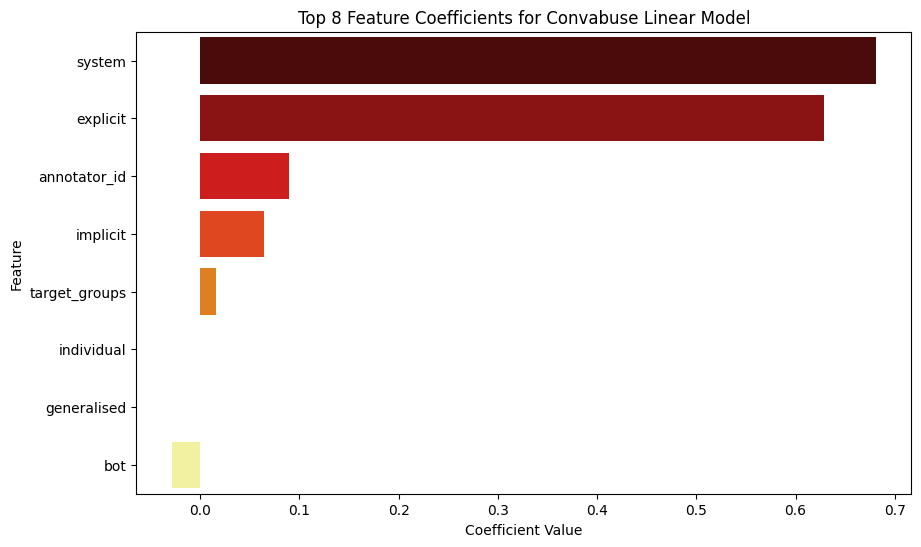

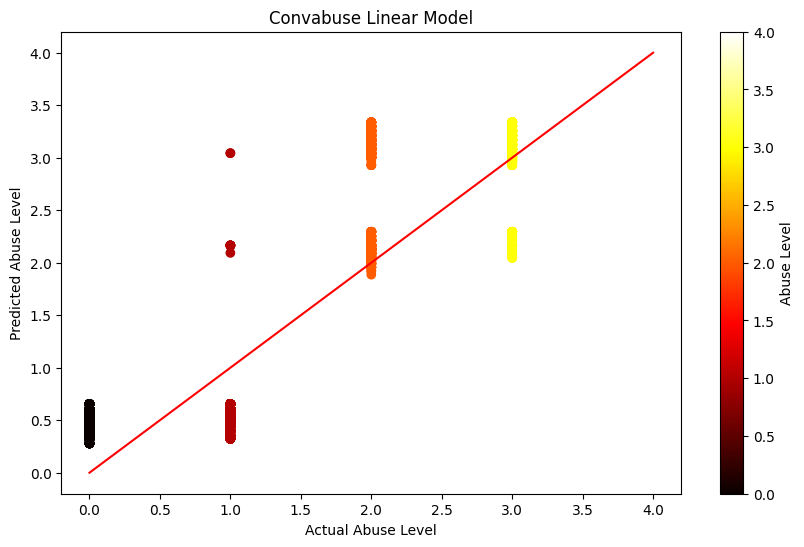

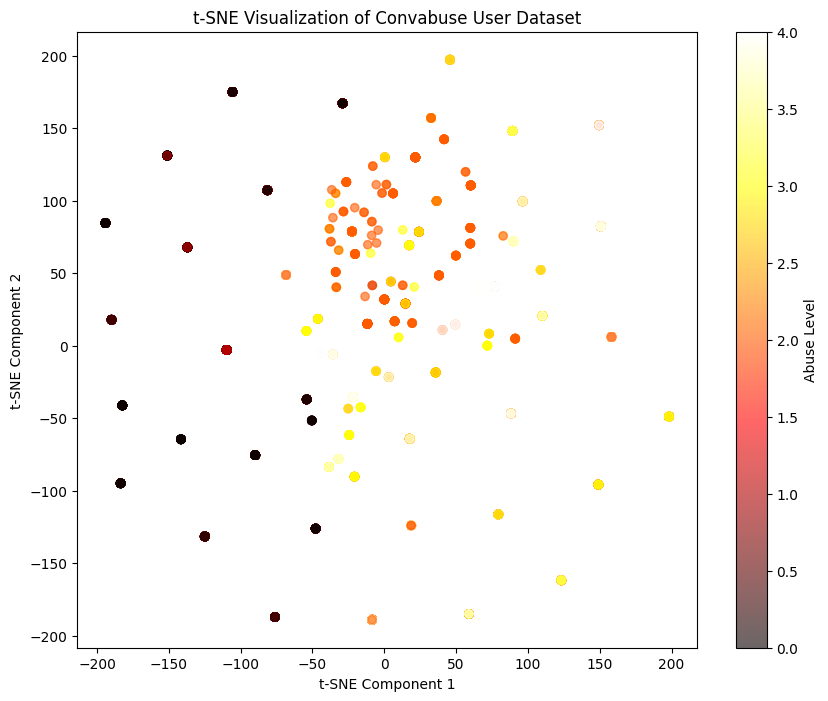

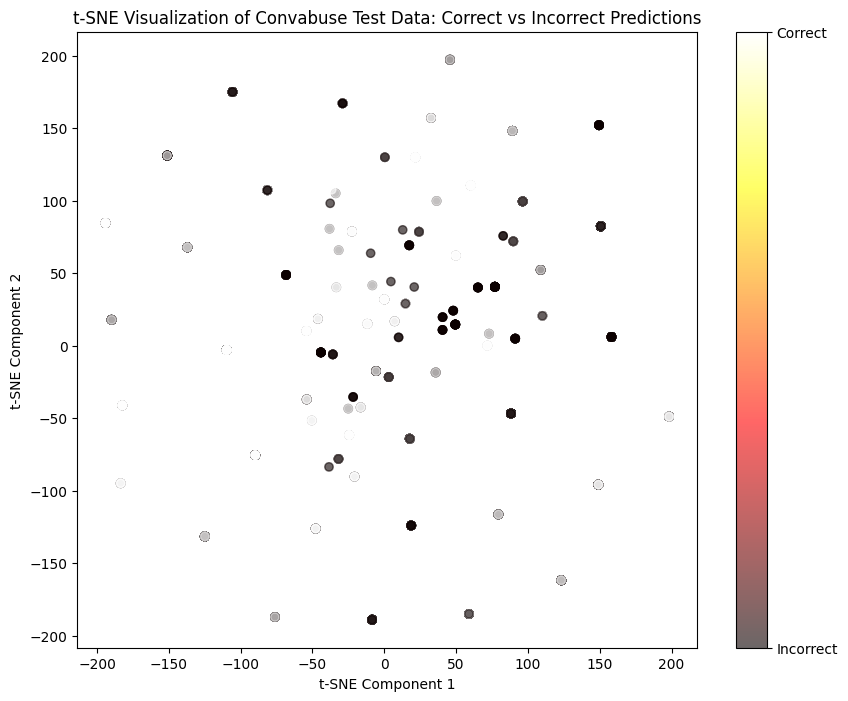

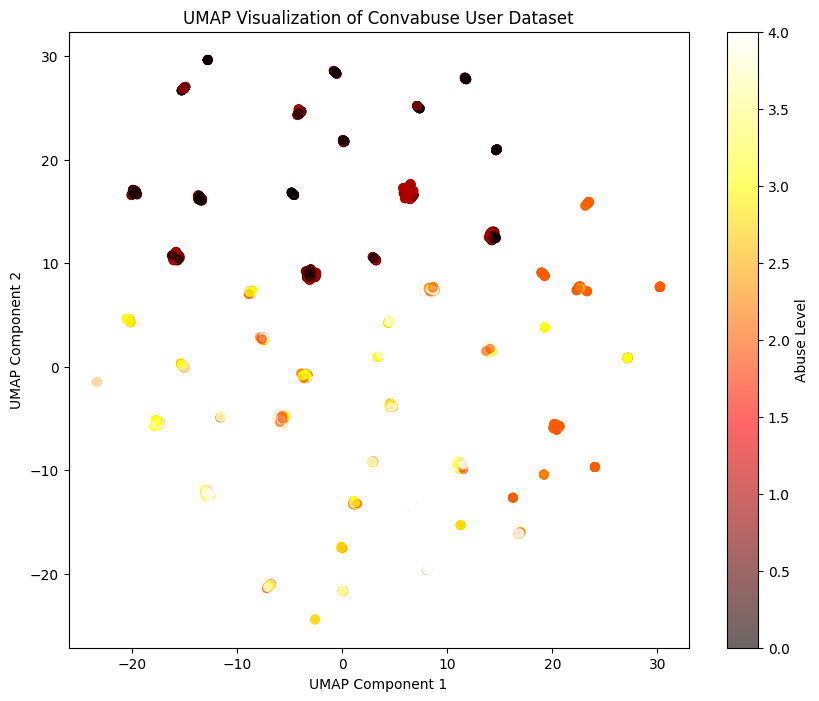

In [24]:
# Perform linear regression on the convabuse dataset
convabuse_linear_rmse, convabuse_linear_r2, convabuse_linear_coefficients, convabuse_top_10_coefficients, convabuse_tsne, convabuse_umap = linear_modeling("Convabuse", convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test, "Abuse Level")

RMSE: 0.3349200486741203
R2: 0.5513142439844996
Top Coefficients
{'original': np.float64(0.10320610623148284), 'target_groups': np.float64(0.0016548506857611742), 'annotator': np.float64(-0.02443082149305916), 'type': np.float64(-0.37591947687307)}
Linear Coefficients
{'type': np.float64(-0.37591947687307), 'annotator': np.float64(-0.02443082149305916), 'target_groups': np.float64(0.0016548506857611742), 'original': np.float64(0.10320610623148284)}


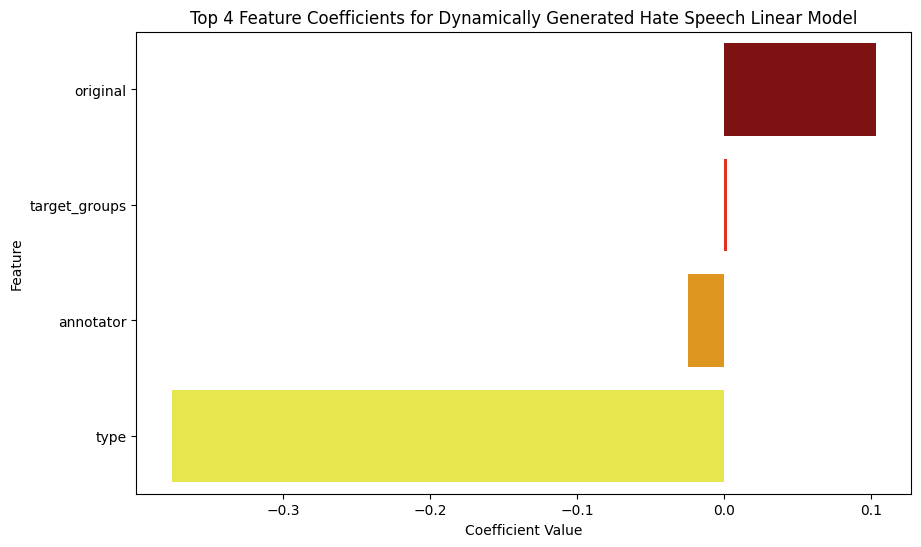

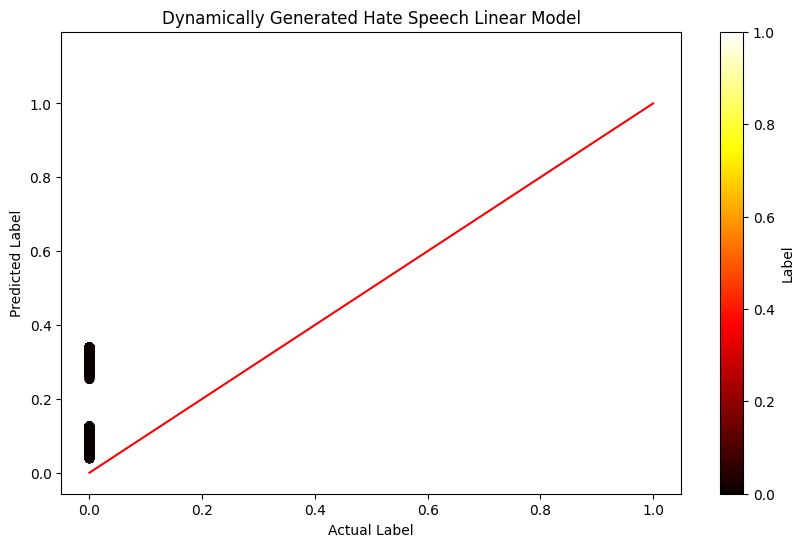

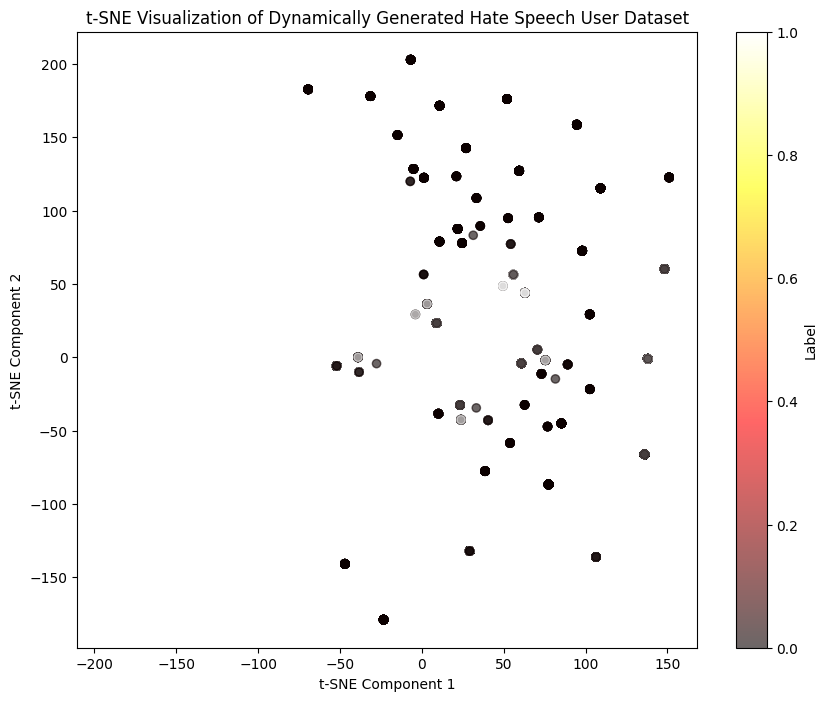

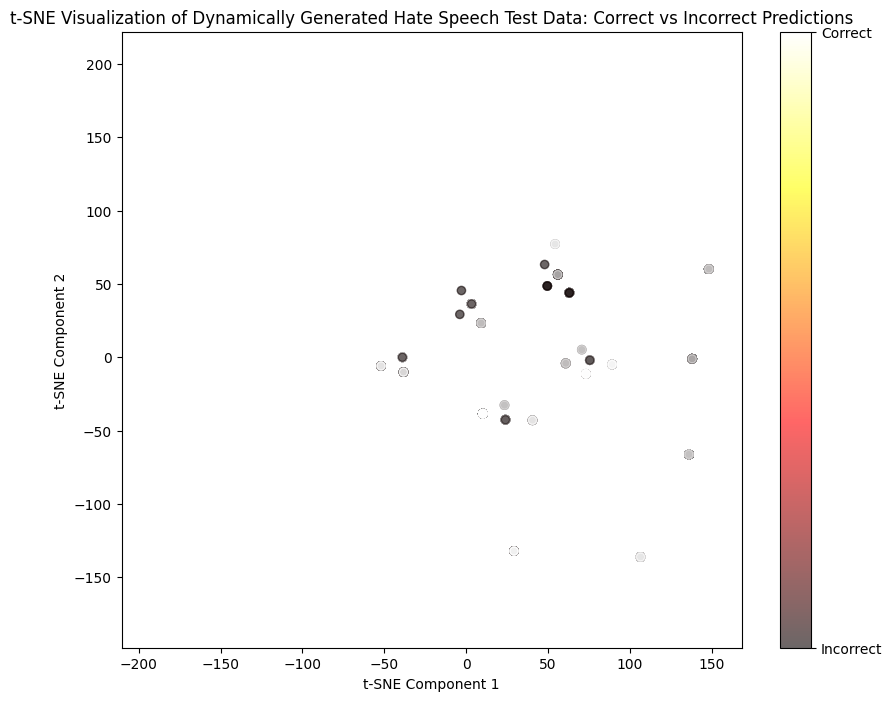

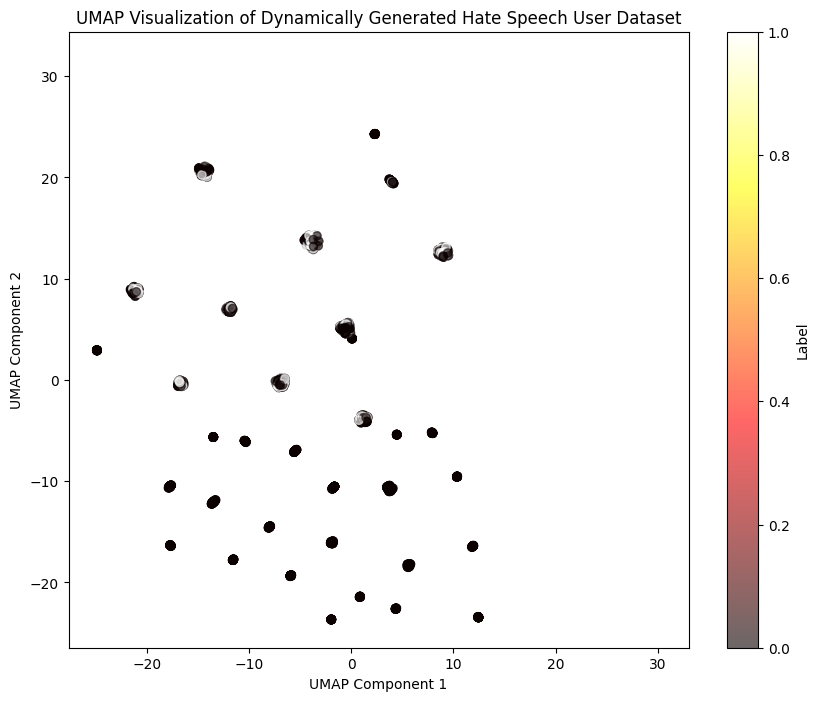

In [25]:
# Perform linear regression on the dynamically generated hate speech dataset
dynamically_generated_hate_speech_linear_rmse, dynamically_generated_hate_speech_linear_r2, dynamically_generated_hate_speech_linear_coefficients, dynamically_generated_hate_speech_top_10_coefficients, dynamically_generated_hate_speech_tsne, dynamically_generated_hate_speech_umap = linear_modeling("Dynamically Generated Hate Speech", dynamically_generated_hate_speech_X_train, dynamically_generated_hate_speech_X_test, dynamically_generated_hate_speech_y_train, dynamically_generated_hate_speech_y_test, "Label")

RMSE: 3.541689781263739e-13
R2: 1.0
Top Coefficients
{'High profanity parents': np.float64(22.62607588258721), 'Toxic parent tweets': np.float64(19.046488905314188), 'High profanity replies': np.float64(9.228602617147782), 'High identity_attack parents': np.float64(7.643457635726357), 'Toxic replies to non-toxic parents': np.float64(7.218152828721707), 'Toxic replies': np.float64(7.118695153005049), 'High insult replies': np.float64(3.950447630338974), 'High toxicity parents': np.float64(2.9402776104678363), 'High insult parents': np.float64(2.918259903174647), 'High threat parents': np.float64(1.332163214068955)}
Linear Coefficients
{'Parent tweets': np.float64(0.2759342865301781), 'Replies to parents': np.float64(0.0745899087031816), 'Avg replies per parent': np.float64(2.3092638912203256e-14), 'Parent tweets with replies': np.float64(-8.770761894538737e-14), 'Avg replies per parent with replies': np.float64(-1.4011014570769476e-13), 'Toxic parent tweets': np.float64(19.0464889053141

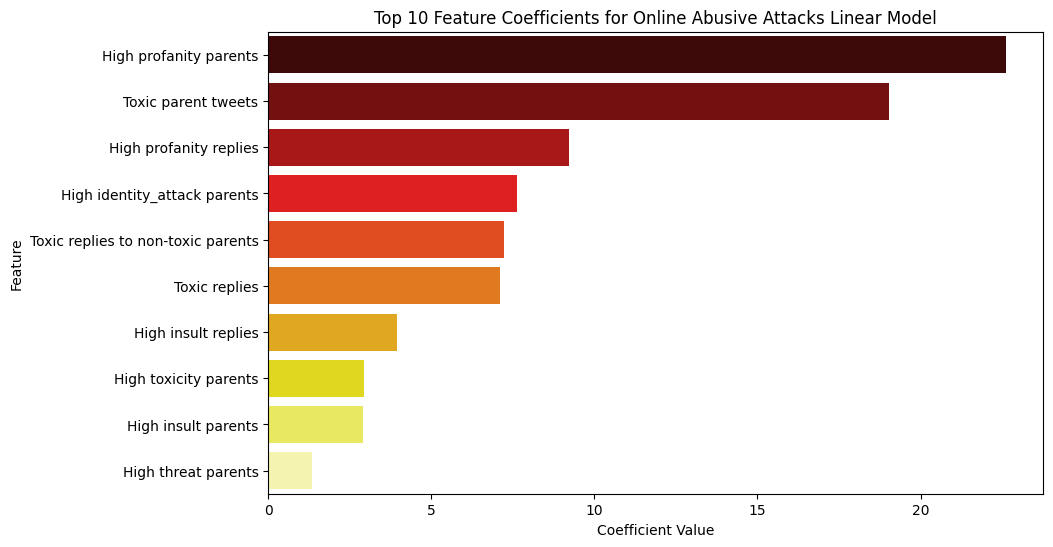

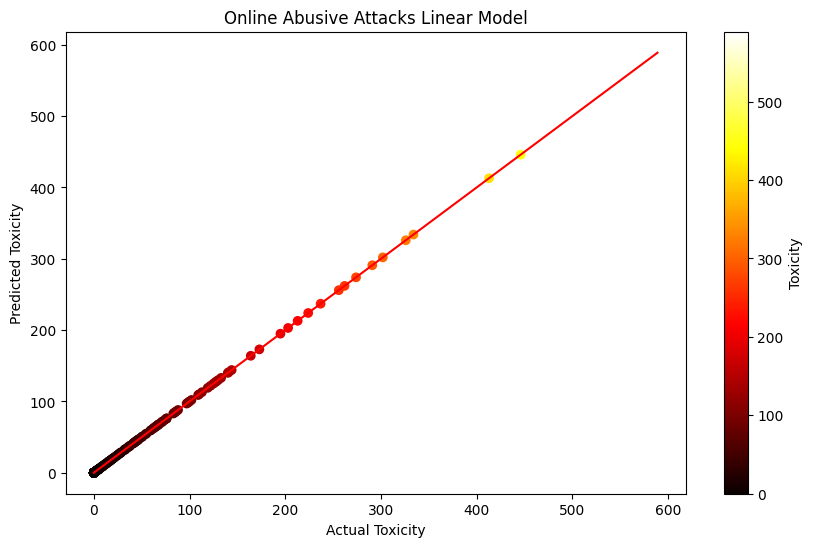

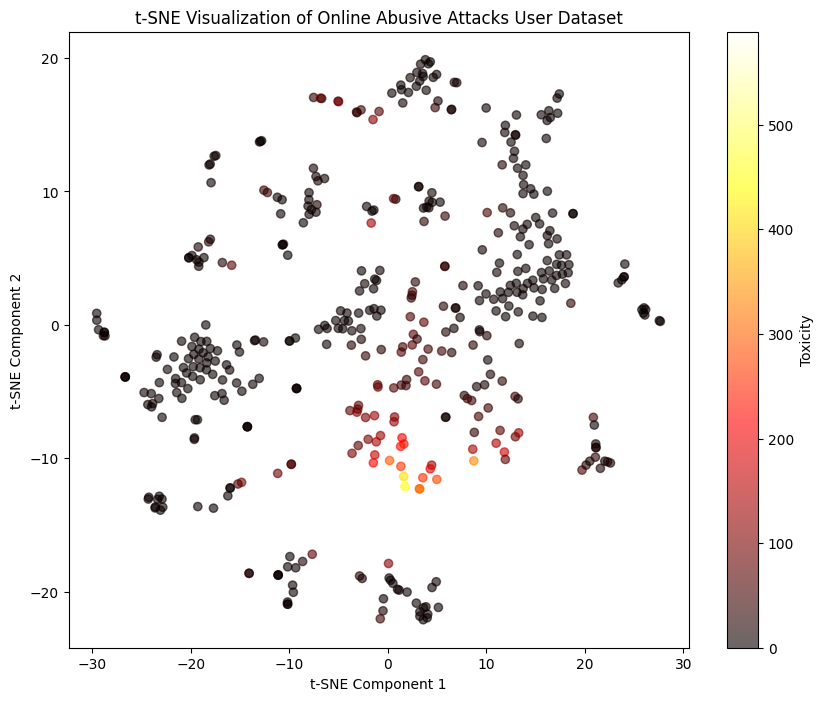

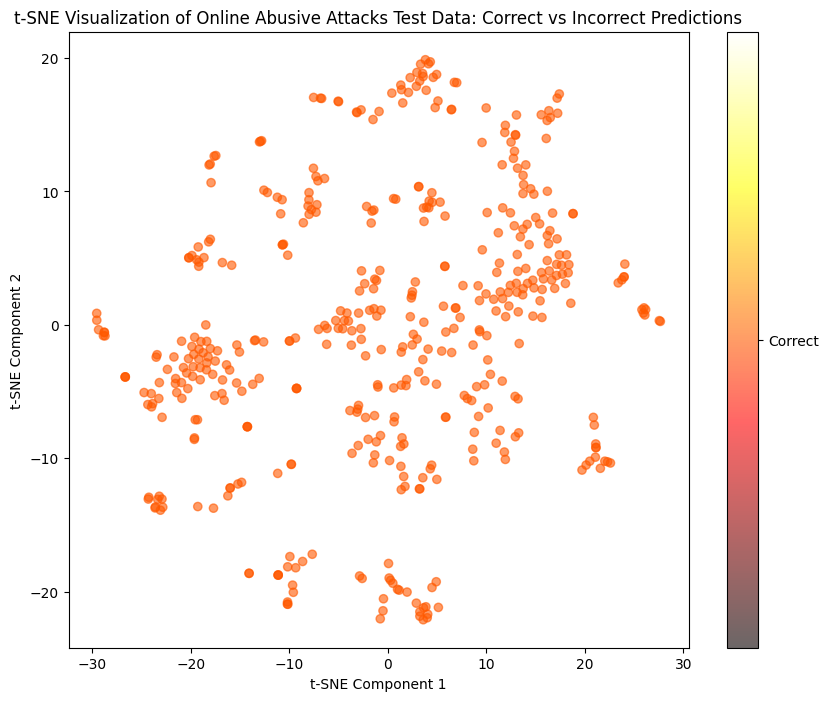

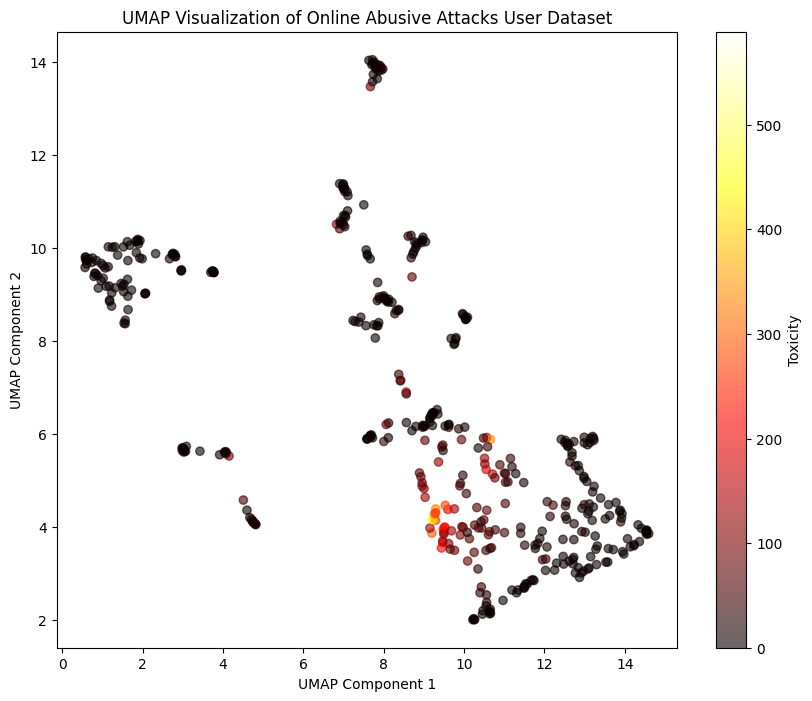

In [26]:
# Perform linear regression on the convabuse dataset
online_abusive_attacks_linear_rmse, online_abusive_attacks_linear_r2, online_abusive_attacks_linear_coefficients, online_abusive_attacks_top_10_coefficients, online_abusive_attacks_tsne, online_abusive_attacks_umap = linear_modeling("Online Abusive Attacks", online_abusive_attacks_X_train, online_abusive_attacks_X_test, online_abusive_attacks_y_train, online_abusive_attacks_y_test, "Toxicity")

RMSE: 0.4710881863988015
R2: 0.11230368254195222
Top Coefficients
{'West': np.float64(0.0), 'Trump': np.float64(-0.12802209933773415), 'Biden': np.float64(-0.13128243216993643)}
Linear Coefficients
{'Trump': np.float64(-0.12802209933773415), 'Biden': np.float64(-0.13128243216993643), 'West': np.float64(0.0)}


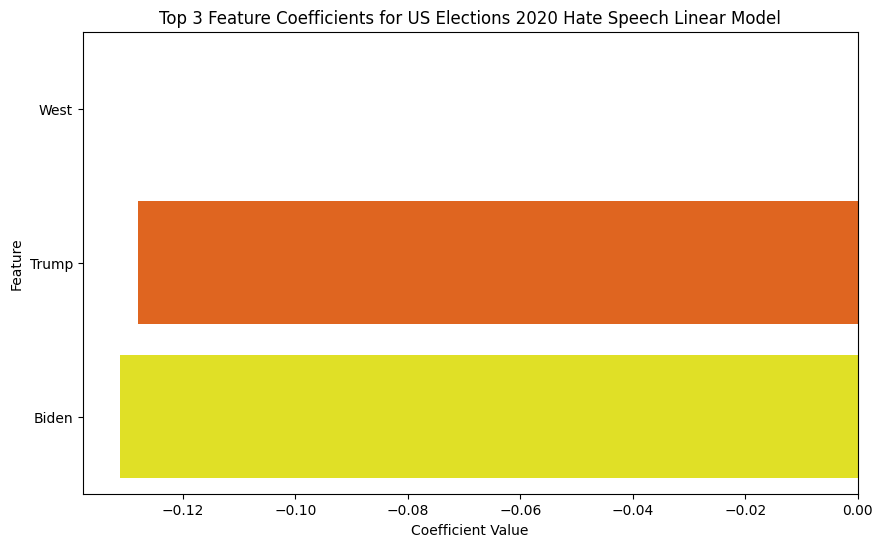

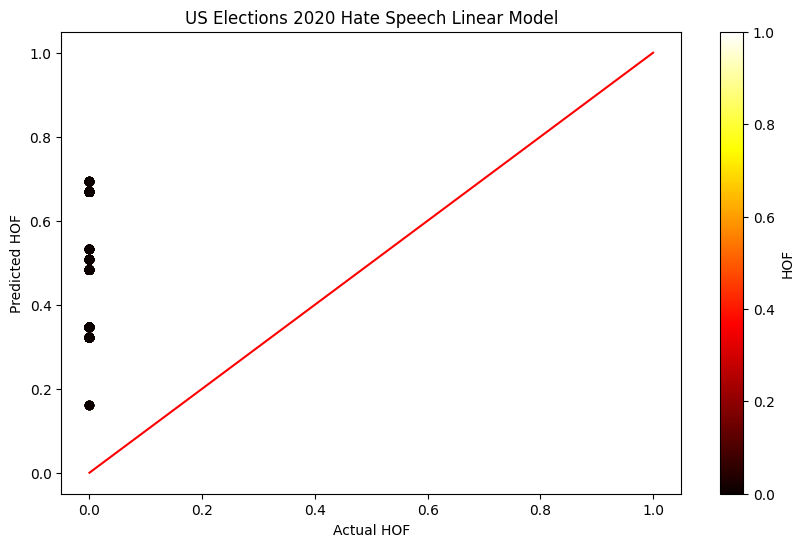

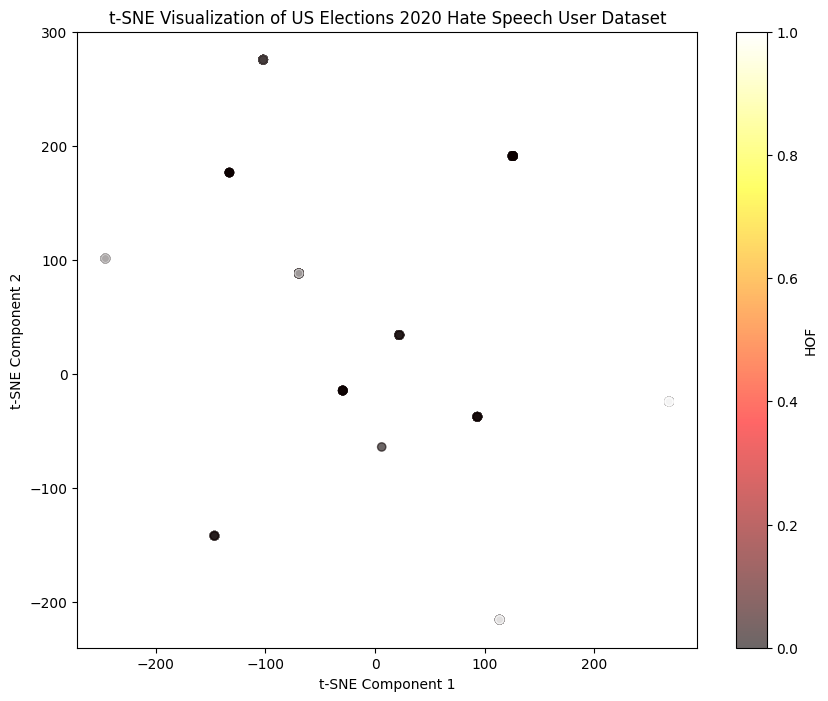

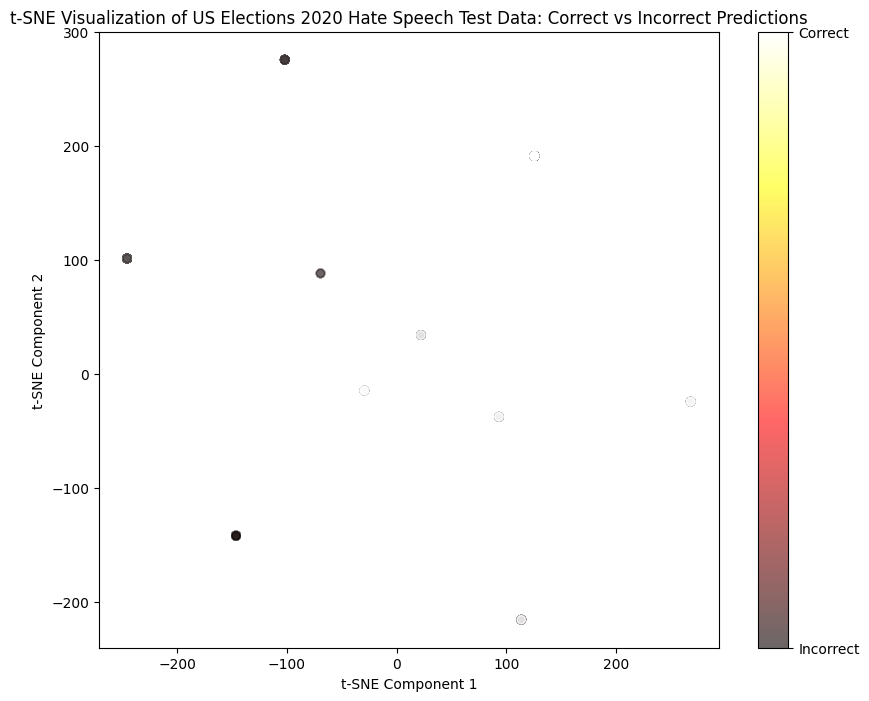

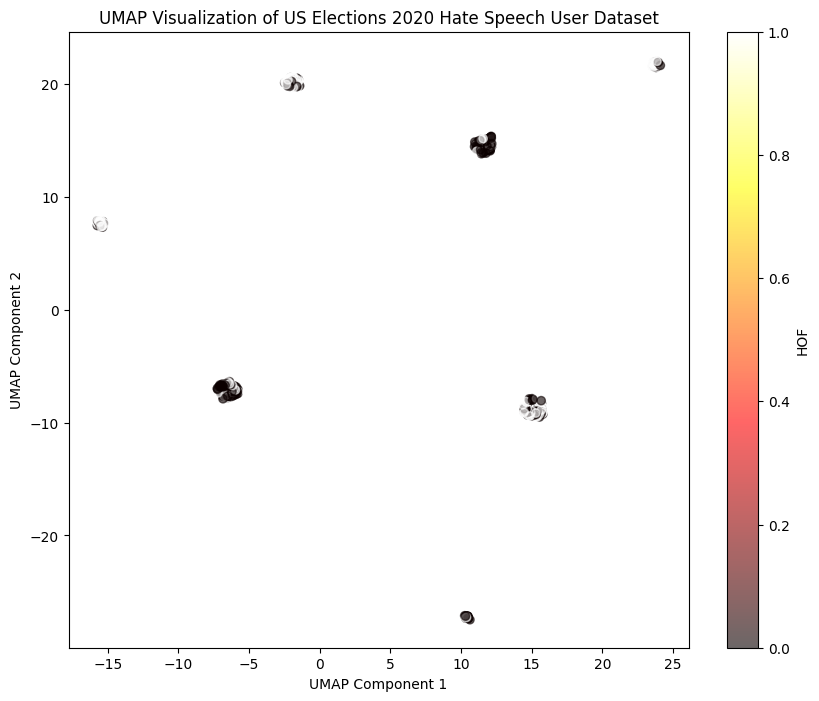

In [27]:
# Perform linear regression on the convabuse dataset
us_elections_2020_hate_speech_linear_rmse, us_elections_2020_hate_speech_linear_r2, us_elections_2020_hate_speech_linear_coefficients, us_elections_2020_hate_speech_top_10_coefficients, us_elections_2020_hate_speech_tsne, us_elections_2020_hate_speech_umap = linear_modeling("US Elections 2020 Hate Speech", us_elections_2020_hate_speech_X_train, us_elections_2020_hate_speech_X_test, us_elections_2020_hate_speech_y_train, us_elections_2020_hate_speech_y_test, "HOF")

RMSE: 1.0232123851766173
R2: 0.1625856853299691
Top Coefficients
{'sadness_annotator_sentiment': np.float64(0.18032698488753068), 'explicit': np.float64(0.16990696745053083), 'anger_annotator_sentiment': np.float64(0.0932830496886426), 'fear_annotator_sentiment': np.float64(0.06250618770340158), 'confusion_annotator_sentiment': np.float64(0.04534736562804176), 'Abusive': np.float64(0.021654741481327115), 'disgust_annotator_sentiment': np.float64(0.016291493082763547), 'Very Abusive': np.float64(0.015003930830138193), 'shock_annotator_sentiment': np.float64(0.013816620595228271), 'Very Strongly Abusive': np.float64(-0.005984897596548724)}
Linear Coefficients
{'shock_annotator_sentiment': np.float64(0.013816620595228271), 'anger_annotator_sentiment': np.float64(0.0932830496886426), 'confusion_annotator_sentiment': np.float64(0.04534736562804176), 'sadness_annotator_sentiment': np.float64(0.18032698488753068), 'indifference_annotator_sentiment': np.float64(-0.08693619736017974), 'disgust_

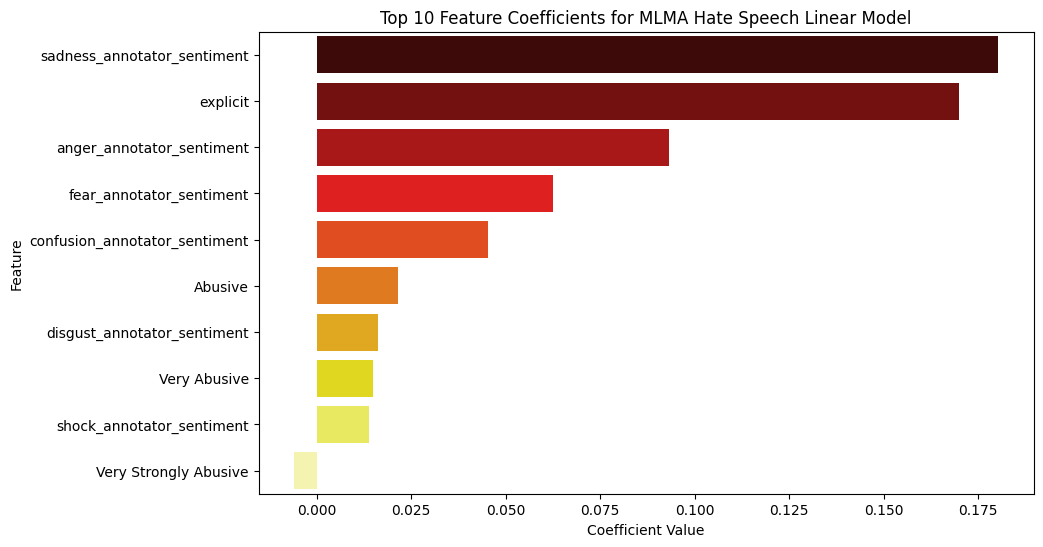

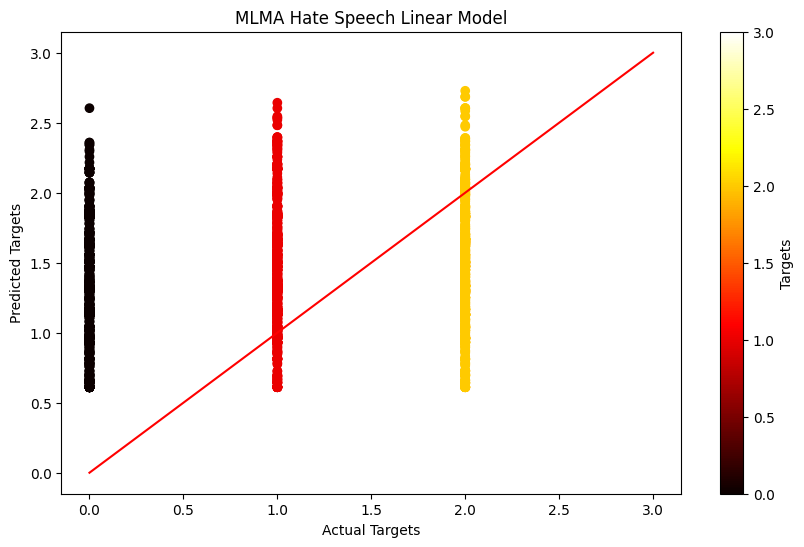

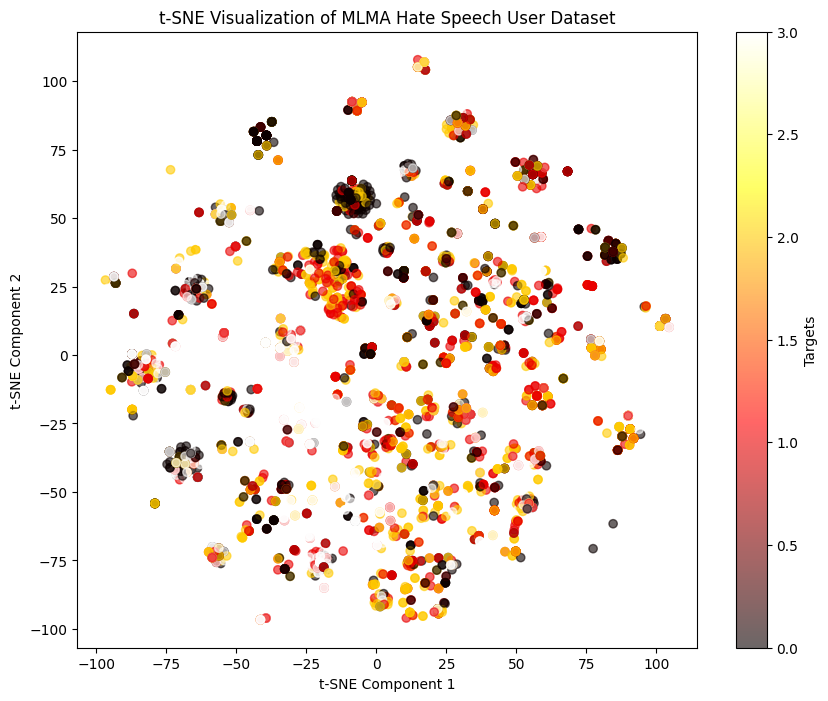

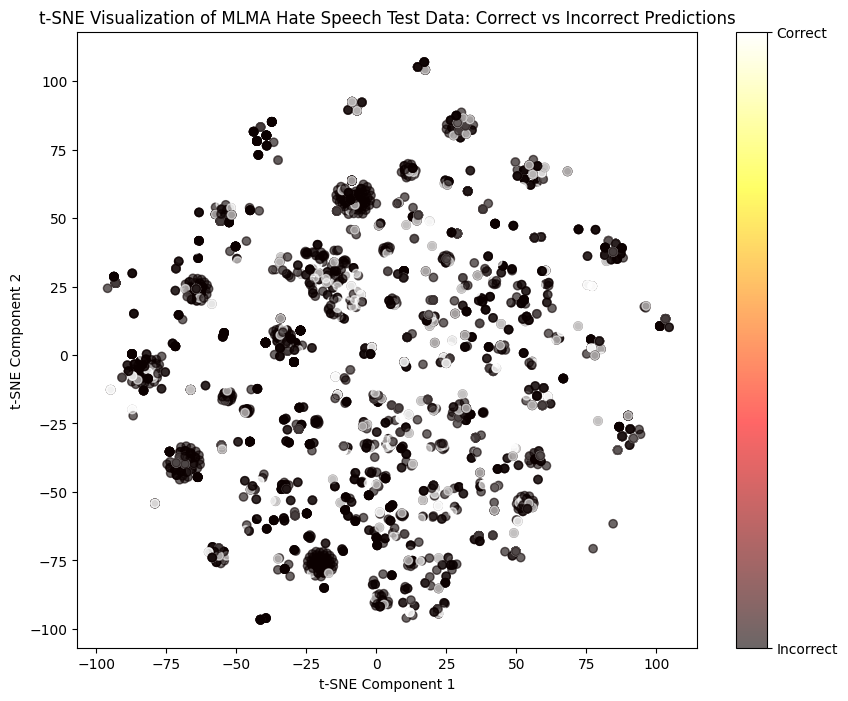

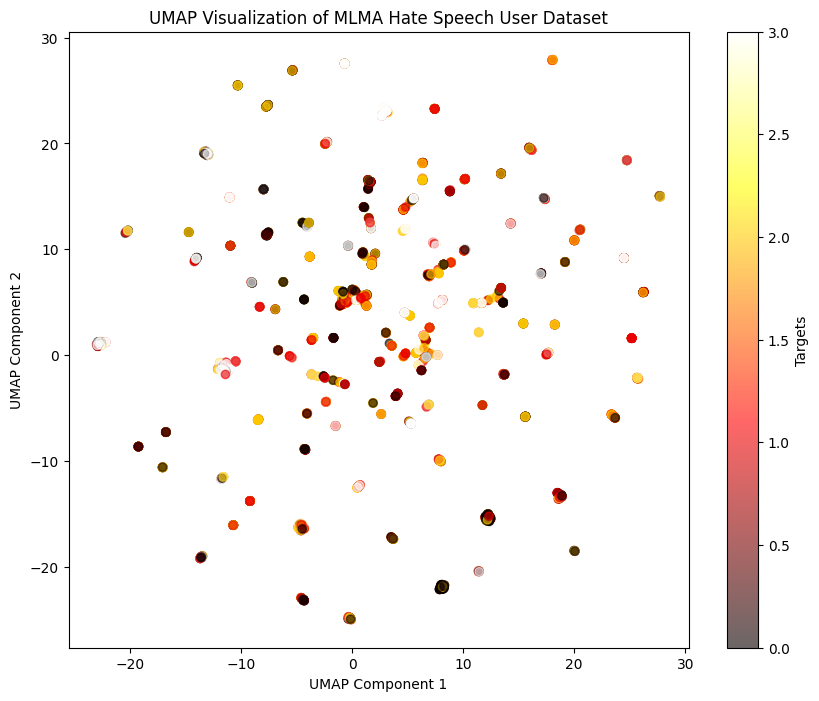

In [28]:
# Perform linear regression on the convabuse dataset
mlma_hate_speech_linear_rmse, mlma_hate_speech_linear_r2, mlma_hate_speech_linear_coefficients, mlma_hate_speech_top_10_coefficients, mlma_hate_speech_tsne, mlma_hate_speech_umap = linear_modeling("MLMA Hate Speech", mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test, "Targets")

In [29]:
pickle_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/pickle/'

# Create two dictionaries for the t-SNE and UMAP embeddings for each dataset
linear_TSNE_dict = {
    "Convabuse": convabuse_tsne,
    "Dynamically Generated Hate Speech": dynamically_generated_hate_speech_tsne,
    "Online Abusive Attacks": online_abusive_attacks_tsne,
    "US Elections 2020 Hate Speech": us_elections_2020_hate_speech_tsne,
    "MLMA Hate Speech": mlma_hate_speech_tsne
}

linear_UMAP_dict = {
    "Convabuse": convabuse_umap,
    "Dynamically Generated Hate Speech": dynamically_generated_hate_speech_umap,
    "Online Abusive Attacks": online_abusive_attacks_umap,
    "US Elections 2020 Hate Speech": us_elections_2020_hate_speech_umap,
    "MLMA Hate Speech": mlma_hate_speech_umap
}

# Pickle both dictionaries
with open(f'{pickle_path}linear-TSNE-dict-resampled.pkl', 'wb') as f:
    pickle.dump(linear_TSNE_dict, f)
with open(f'{pickle_path}linear-UMAP-dict-resampled.pkl', 'wb') as f:
    pickle.dump(linear_UMAP_dict, f)

In [30]:
# Create a dictionary where each dataset maps to its RMSE and R2
linear_model_summary_data = [
    {
        "Model": "Linear Regression",
        "Dataset": "Convabuse",
        "RMSE": convabuse_linear_rmse,
        "R2": convabuse_linear_r2,
        "Coefficients": convabuse_linear_coefficients,
        "Feature Coefficients": convabuse_top_10_coefficients
    },
    {
        "Model": "Linear Regression",
        "Dataset": "Dynamically Generated Hate Speech",
        "RMSE": dynamically_generated_hate_speech_linear_rmse,
        "R2": dynamically_generated_hate_speech_linear_r2,
        "Coefficients": dynamically_generated_hate_speech_linear_coefficients,
        "Feature Coefficients": dynamically_generated_hate_speech_top_10_coefficients
    },
    {
        "Model": "Linear Regression",
        "Dataset": "Online Abusive Attacks",
        "RMSE": online_abusive_attacks_linear_rmse,
        "R2": online_abusive_attacks_linear_r2,
        "Coefficients": online_abusive_attacks_linear_coefficients,
        "Feature Coefficients": online_abusive_attacks_top_10_coefficients
    },
    {
        "Model": "Linear Regression",
        "Dataset": "US Elections 2020 Hate Speech",
        "RMSE": us_elections_2020_hate_speech_linear_rmse,
        "R2": us_elections_2020_hate_speech_linear_r2,
        "Coefficients": us_elections_2020_hate_speech_linear_coefficients,
        "Feature Coefficients": us_elections_2020_hate_speech_top_10_coefficients
    },
    {
        "Model": "Linear Regression",
        "Dataset": "MLMA Hate Speech",
        "RMSE": mlma_hate_speech_linear_rmse,
        "R2": mlma_hate_speech_linear_r2,
        "Coefficients": mlma_hate_speech_linear_coefficients,
        "Feature Coefficients": mlma_hate_speech_top_10_coefficients
    }
]

# Convert to DataFrame (datasets become rows, metrics are columns)
linear_model_summary = pd.DataFrame(linear_model_summary_data)
linear_model_summary["Balance"] = "Resampled"
linear_model_summary

,Model,Dataset,RMSE,R2,Coefficients,Feature Coefficients,Balance
0,Linear Regression,Convabuse,6.394386e-01,0.795539,"{'annotator_id': 0.08913254214796316, 'bot': -...","{'system': 0.6812356291906492, 'explicit': 0.6...",Resampled
1,Linear Regression,Dynamically Generated Hate Speech,3.349200e-01,0.551314,"{'type': -0.37591947687307, 'annotator': -0.02...","{'original': 0.10320610623148284, 'target_grou...",Resampled
2,Linear Regression,Online Abusive Attacks,3.541690e-13,1.000000,"{'Parent tweets': 0.2759342865301781, 'Replies...","{'High profanity parents': 22.62607588258721, ...",Resampled
3,Linear Regression,US Elections 2020 Hate Speech,4.710882e-01,0.112304,"{'Trump': -0.12802209933773415, 'Biden': -0.13...","{'West': 0.0, 'Trump': -0.12802209933773415, '...",Resampled
4,Linear Regression,MLMA Hate Speech,1.023212e+00,0.162586,{'shock_annotator_sentiment': 0.01381662059522...,{'sadness_annotator_sentiment': 0.180326984887...,Resampled


In [31]:
linear_model_summary.to_csv("/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/model1_linear-model-summary_resampled.csv", index=False)